# CUAD Dataset Exploration
**AI-Powered Legal Document Analysis System** · BRAC University · Person 1 (Code & Data)

This notebook walks through the CUAD dataset so the rest of the team can see what we're working with. It loads the data, reports the key numbers, lists all 41 clause categories, and shows **five example contracts** with some of their real clauses. It runs on the full `CUADv1.json` if you've downloaded it, and falls back to the bundled 5-contract sample if you haven't.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import (load_cuad, compute_stats, annotations_per_category,
                         contracts_per_category, get_example_clauses)

# Prefer the full dataset; fall back to the bundled sample
FULL = '../data/CUADv1.json'
SAMPLE = '../data/sample/cuad_sample_5.json'
path = FULL if os.path.exists(FULL) else SAMPLE
data, version = load_cuad(path)
print(f'Loaded: {os.path.basename(path)}  |  version={version}  |  contracts={len(data)}')

Loaded: CUADv1.json  |  version=aok_v1.0  |  contracts=510


## 1. The numbers
A quick summary of the dataset, computed straight from the file rather than quoted from the paper.

In [2]:
stats = compute_stats(data)
summary = pd.DataFrame({
    'Metric': ['Contracts', 'Clause categories', 'Total questions',
               'Total annotation spans', 'Empty (clause absent)', 'Avg contract length (chars)'],
    'Value':  [stats['contracts'], stats['categories'], stats['total_questions'],
               stats['total_annotations'], stats['impossible'], stats['avg_context_chars']]
})
summary

,Metric,Value
0,Contracts,510
1,Clause categories,41
2,Total questions,20910
3,Total annotation spans,13823
4,Empty (clause absent),14208
5,Avg contract length (chars),52563


For context, the paper reports over 13,000 expert annotations across 25 contract types and 9,283 pages, each reviewed at least four times — work the authors estimate was worth more than **$2,000,000**.

## 2. The 41 clause categories
These are the clause types CUAD labels. They're also exactly the categories Afnan scores for risk and Shoyeb summarizes, so everything stays consistent.

In [3]:
cats = pd.DataFrame({'#': range(1, len(stats['category_names'])+1),
                     'Category': stats['category_names']})
pd.set_option('display.max_rows', 50)
cats

,#,Category
0,1,Document Name
1,2,Parties
2,3,Agreement Date
3,4,Effective Date
4,5,Expiration Date
5,6,Renewal Term
6,7,Notice Period To Terminate Renewal
7,8,Governing Law
8,9,Most Favored Nation
9,10,Non-Compete


## 3. Five example contracts
For each of the first five contracts, here's its length, how many of the 41 clause types actually appear in it, and a few of the real clauses that were pulled out.

In [4]:
for i, c in enumerate(data[:5], 1):
    text = c['paragraphs'][0]['context']
    present = [q['id'].split('__')[-1] for q in c['paragraphs'][0]['qas'] if q['answers']]
    print(f'{"="*78}\nEXAMPLE {i}: {c["title"]}')
    print(f'  Contract length : {len(text):,} chars')
    print(f'  Categories present: {len(present)} / 41')
    print('  Sample extracted clauses:')
    for cat, clause in get_example_clauses(c, limit=3):
        snippet = clause.replace(chr(10), " ")[:140]
        print(f'    - [{cat}] {snippet}{"..." if len(clause) > 140 else ""}')

EXAMPLE 1: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
  Contract length : 54,290 chars
  Categories present: 19 / 41
  Sample extracted clauses:
    - [Document Name] DISTRIBUTOR AGREEMENT
    - [Parties] Distributor
    - [Agreement Date] 7th day of September, 1999.
EXAMPLE 2: WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMENT
  Contract length : 70,383 chars
  Categories present: 12 / 41
  Sample extracted clauses:
    - [Document Name] Promotion and Distribution Agreement
    - [Parties] Distributor
    - [Effective Date] 1 August 2011
EXAMPLE 3: LohaCompanyltd_20191209_F-1_EX-10.16_11917878_EX-10.16_Supply Agreement
  Contract length : 11,475 chars
  Categories present: 6 / 41
  Sample extracted clauses:
    - [Document Name] SUPPLY CONTRACT
    - [Parties] The seller:
    - [Expiration Date] The Contract is valid for 5 years, beginning from and ended on .
EXAMPLE 4: CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WEB SITE HOSTING AGREEMENT
  Contract leng

## 4. How common is each clause?
Some clauses turn up in almost every contract while others are rare. That imbalance is worth knowing before we train anything.

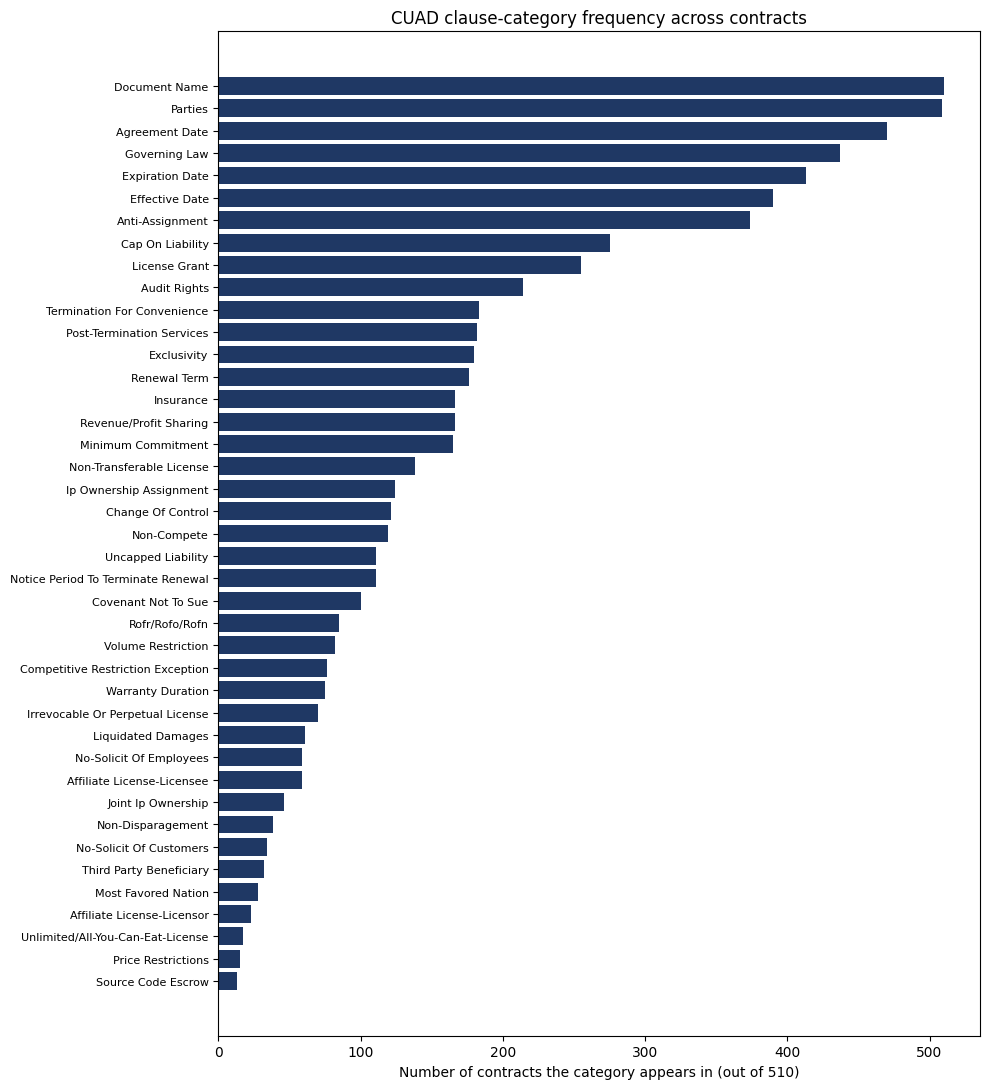

Most common : Document Name, Parties, Agreement Date
Least common: Unlimited/All-You-Can-Eat-License, Price Restrictions, Source Code Escrow


In [5]:
cpc = contracts_per_category(data)
ordered = sorted(cpc.items(), key=lambda kv: kv[1], reverse=True)
labels = [k for k, _ in ordered]
values = [v for _, v in ordered]

plt.figure(figsize=(10, 11))
plt.barh(range(len(labels)), values, color='#1F3864')
plt.yticks(range(len(labels)), labels, fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel(f'Number of contracts the category appears in (out of {len(data)})')
plt.title('CUAD clause-category frequency across contracts')
plt.tight_layout()
plt.show()

print('Most common :', ', '.join(labels[:3]))
print('Least common:', ', '.join(labels[-3:]))

## What this tells us

- CUAD is set up as **question answering**: each contract gets asked the same 41 questions, and an answer span means that clause is present.
- The clauses are **very unevenly distributed** — things like *Document Name*, *Parties* and *Governing Law* show up in nearly every contract, while *Third Party Beneficiary* or *Volume Restriction* barely appear. The extraction stage will have to cope with that imbalance.
- The numbers here feed straight into Afnan's **risk taxonomy** (same 41 categories, scored High/Medium/Low) and Shoyeb's **summarization and conflict** work, so all three parts of the project are built on the same foundation.